In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

In [ ]:
plt.style.available

In [32]:
msft=pd.read_csv(r'C:\Users\bedla\Documents\Ausbildung_Informatik\1_Praktikum\Praktikum_Daten-_und_Prozessanalyse\energy_trading\PyCharm_Notebook\Data\msft.csv', index_col='Date', parse_dates=['Date'])
msft

,Price,Returns
Date,,
2014-10-01,38.880157,NaN
2014-10-02,38.761566,-0.003050
2014-10-03,39.041096,0.007212
2014-10-06,39.041096,0.000000
2014-10-07,38.566757,-0.012150
...,...,...
2021-05-24,241.744537,0.022882
2021-05-25,242.650665,0.003748
2021-05-26,242.428940,-0.000914


In [33]:
msft['log_returns']=np.log(msft.Price/msft.Price.shift()) #daily Log Returns
msft

,Price,Returns,log_returns
Date,,,
2014-10-01,38.880157,NaN,NaN
2014-10-02,38.761566,-0.003050,-0.003055
2014-10-03,39.041096,0.007212,0.007186
2014-10-06,39.041096,0.000000,0.000000
2014-10-07,38.566757,-0.012150,-0.012224
...,...,...,...
2021-05-24,241.744537,0.022882,0.022624
2021-05-25,242.650665,0.003748,0.003741
2021-05-26,242.428940,-0.000914,-0.000914


In [34]:
msft.head(50)

,Price,Returns,log_returns
Date,,,
2014-10-01,38.880157,NaN,NaN
2014-10-02,38.761566,-0.003050,-0.003055
2014-10-03,39.041096,0.007212,0.007186
2014-10-06,39.041096,0.000000,0.000000
2014-10-07,38.566757,-0.012150,-0.012224
2014-10-08,39.625580,0.027454,0.027084
2014-10-09,38.837811,-0.019880,-0.020081
2014-10-10,37.296154,-0.039695,-0.040504
2014-10-13,36.974277,-0.008630,-0.008668


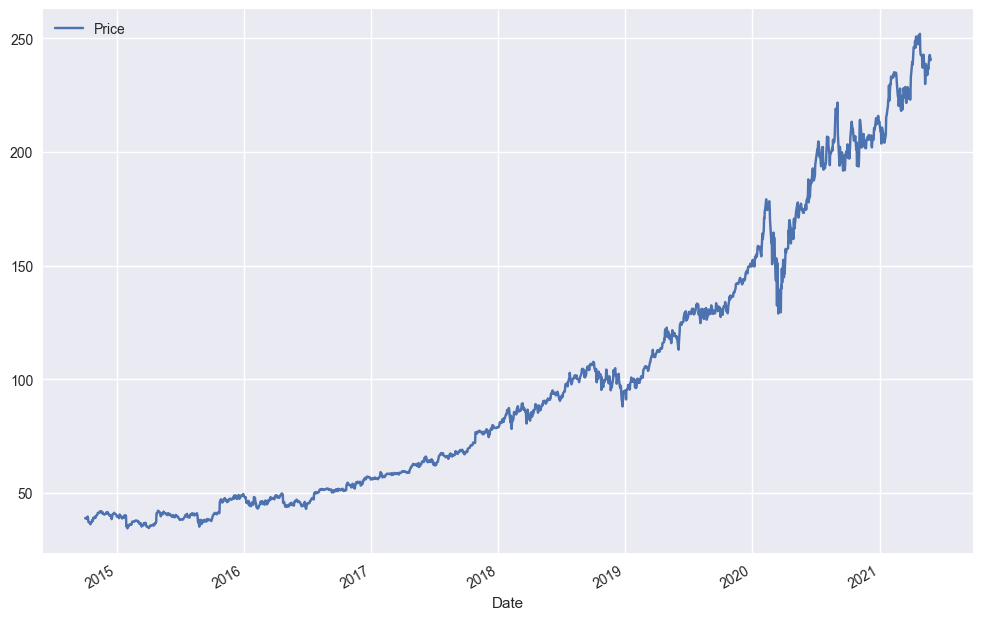

In [35]:
msft.Price.plot(figsize=(12,8))
plt.legend()
plt.show()

In [36]:
monthly=msft.Price.resample('ME').last()
monthly

Date
2014-10-31     39.769577
2014-11-30     40.753494
2014-12-31     39.594208
2015-01-31     34.437153
2015-02-28     37.643967
                 ...    
2021-01-31    222.574844
2021-02-28    223.491440
2021-03-31    226.751770
2021-04-30    242.534058
2021-05-31    240.684128
Freq: ME, Name: Price, Length: 80, dtype: float64

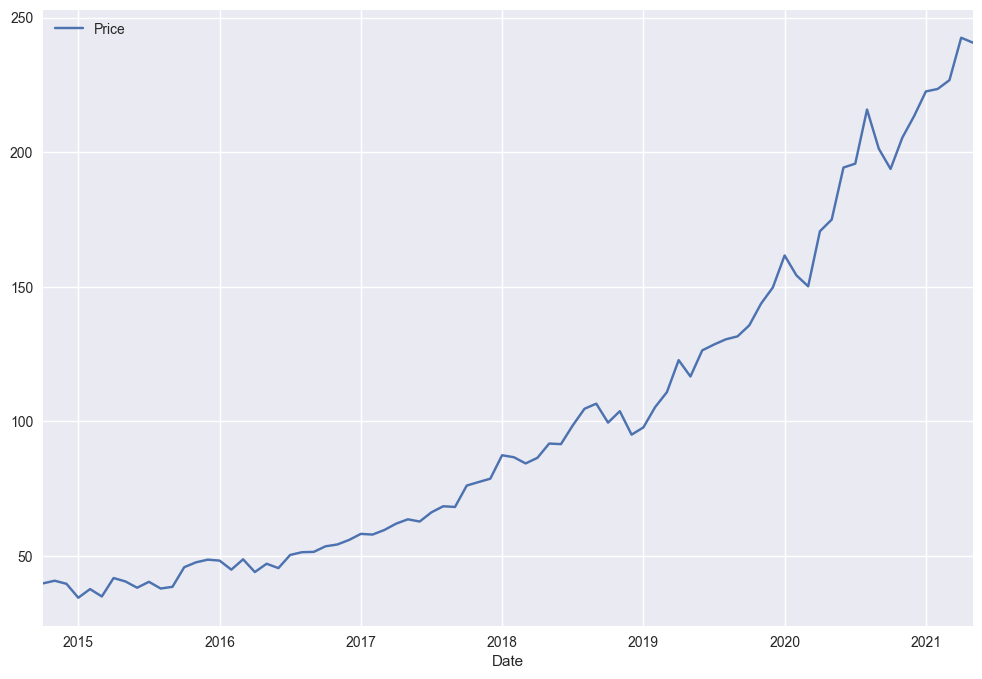

In [37]:
monthly.plot(figsize=(12,8))
plt.legend()
plt.show()

# How will the Mean-Variance Analysis change the smoothed Data?

In [47]:
freqs=['YE','QE','ME','W-FRI','D']
periods=[1,4,12,52,252]
ann_mean=[]
ann_std=[]

In [48]:
for i in range(5):
    resamp=msft.Price.resample(freqs[i]).last() # resample
    ann_mean.append(np.log(resamp/resamp.shift()).mean()*periods[i]) # calculated annualized mean
    ann_std.append(np.log(resamp/resamp.shift()).std()*np.sqrt(periods[i])) # calculated annualized std

In [49]:
ann_mean

[np.float64(0.2578289374060155),
 np.float64(0.2776619325910937),
 np.float64(0.27347592564181966),
 np.float64(0.27256850080975786),
 np.float64(0.2749869993180418)]

In [52]:
ann_std

[np.float64(0.1260917896524943),
 np.float64(0.17856139994918105),
 np.float64(0.20430370892962796),
 np.float64(0.23019030044101726),
 np.float64(0.26698705559833197)]

In [53]:
summary=pd.DataFrame(data={'ann_std':ann_std,'ann_mean':ann_mean},index=freqs)
summary

# Hier (Spalte: ann_std) ist zu erkennen, dass das Risiko sinkt mit dem Sinken der Frequenz (von täglich zu jährlich)

,ann_std,ann_mean
YE,0.126092,0.257829
QE,0.178561,0.277662
ME,0.204304,0.273476
W-FRI,0.230190,0.272569
D,0.266987,0.274987


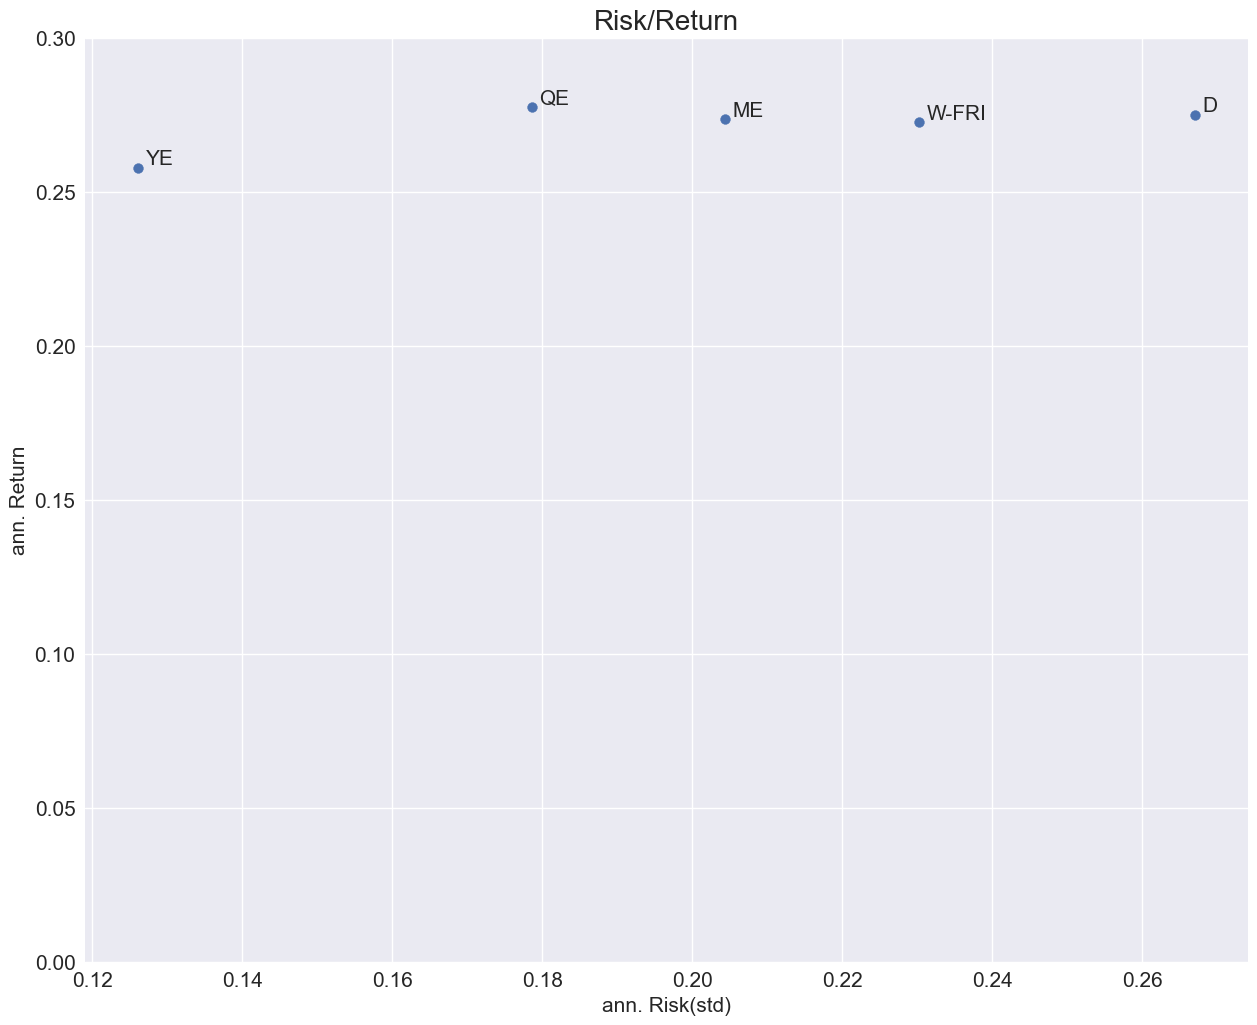

In [54]:
summary.plot(kind='scatter',x='ann_std',y='ann_mean',figsize=(15,12),s=50,fontsize=15)
for i in summary.index:
    plt.annotate(i,xy=(summary.loc[i,'ann_std']+0.001,summary.loc[i,'ann_mean']+0.001),size=15)
plt.ylim(0,0.3)
plt.xlabel('ann. Risk(std)',fontsize=15)
plt.ylabel('ann. Return',fontsize=15)
plt.title('Risk/Return',fontsize=20)
plt.show()

# Smoothing reduces the (observed) Risk.


Dubious Practices:
- Managing (Manipulating) Performance in Performance Reportings.
- Adjusting frequency to investor´s (average) holding period -> Volatility is still there.
- Comparing assets with different pricing frequency and pricing mechanisms -> e.g. real estate with quarterly valuation vs. listed stocks (minutely/hourly/daily prices)

# Take Home: When comparing instruments, frequency of underlaying data must be the same! Don´t compare apples and oranges!